# Delivery regression: report evidence supplement

## tl;dr
The frozen 63-leaf HGB remains the final model: Train MAE **3.9295**, five-fold CV **4.2378**, Test **4.1505** days. This companion fills the same-split references, baseline/variant Train–CV–Test comparison, final-model error diagnostics and interpretation. Latest nested stacking improves CV by approximately 36 seconds and has **no full-training fit or test result**. No model is selected or trained by this notebook.

## Context & Methods
Training contains 64,634 orders, test 31,836; random 67/33, seed 33, same five training folds. Train scores use the exact regressor fitting design, including cross-fitted risk values. CV is the equal-weight fold mean. Both sample and population fold SD are available; neither is a confidence interval. There is no separate validation set.

### Key Assumptions
Archived quote/seller/product attributes are assumed available at purchase. Completed deliveries only. Existing test and CV have informed prior development. All fixed-test interpretation is diagnostic and was not used to reselect features or models.

In [1]:
from pathlib import Path
import pandas as pd
import json
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'bundle_manifest.json').exists())
RESULTS = ROOT/'results/report_supplement'
comparison = pd.read_csv(RESULTS/'tables/train_cv_test_comparison.csv')
assert len(comparison)==15
assert comparison.Train_n.eq(64634).all() and comparison.Test_n.eq(31836).all()
assert comparison.CV_folds.eq(5).all()
print('Fifteen matched rows: references, baselines, variants and final HGB.')

Fifteen matched rows: references, baselines, variants and final HGB.


## Data
The seven-table course archive yields 96,470 eligible completed orders; all 306 targets above 60 days are retained. Inputs and split population are supplied for the report appendix.

In [2]:
display(pd.read_csv(RESULTS/'tables/regression_cohort_flow.csv'))
display(pd.read_csv(RESULTS/'tables/split_population.csv'))

,step,n
0,Source orders,99441
1,Orders marked delivered,96478
2,Delivered missing receipt (excluded),8
3,Eligible completed orders with valid target an...,96470
4,Negative target durations among remaining orders,0
5,Eligible orders missing item records,0
6,Retained valid targets above 60 days,306
7,Missing maximum distance (retained),477
8,Missing average product weight (retained),22


,split,n,purchase_min,purchase_max,mean_days,median_days,above_30_days_n,above_60_days_n,chronology_flag_n
0,train,64634,2016-09-15 12:16:38,2018-08-29 15:00:37,12.584779,10.216574,3086,207,59
1,test,31836,2016-10-03 16:56:50,2018-08-29 14:18:28,12.504290,10.219039,1464,99,25


## Results
### 1. Train–CV–Test
Original OLS/single tree are retained as simple fitted baselines. Enhanced variants are separate rows. Algorithm and input representations both change across parts of this ladder.

,model,Train_MAE_days,CV_MAE_mean_days,CV_MAE_SD_sample_days,Test_MAE_days,Test_RMSE_days,Test_R2
0,Delivery promise,12.7308,12.7308,0.0567,12.7219,15.0933,-1.5854
1,Training mean,6.4437,6.4439,0.0340,6.3743,9.3872,-0.0001
2,Training median,6.1478,6.1480,0.0417,6.0752,9.6616,-0.0594
3,OLS baseline,5.0045,5.0196,0.0423,4.9607,7.8947,0.2926
4,Single-tree baseline,4.9751,5.0585,0.0532,5.0297,8.0311,0.2680
5,Ridge F1,4.9724,4.9836,0.0412,4.9214,7.8537,0.3000
6,RF F1,3.8850,4.7269,0.0532,4.6525,7.5879,0.3466
7,RF log-target F1,3.7645,4.5386,0.0493,4.4542,7.7209,0.3234
8,OLS + time/risk,4.7550,4.7741,0.0465,4.6983,7.5970,0.3450
9,Single tree + time/risk,4.6530,4.7615,0.0417,4.6783,7.6125,0.3423


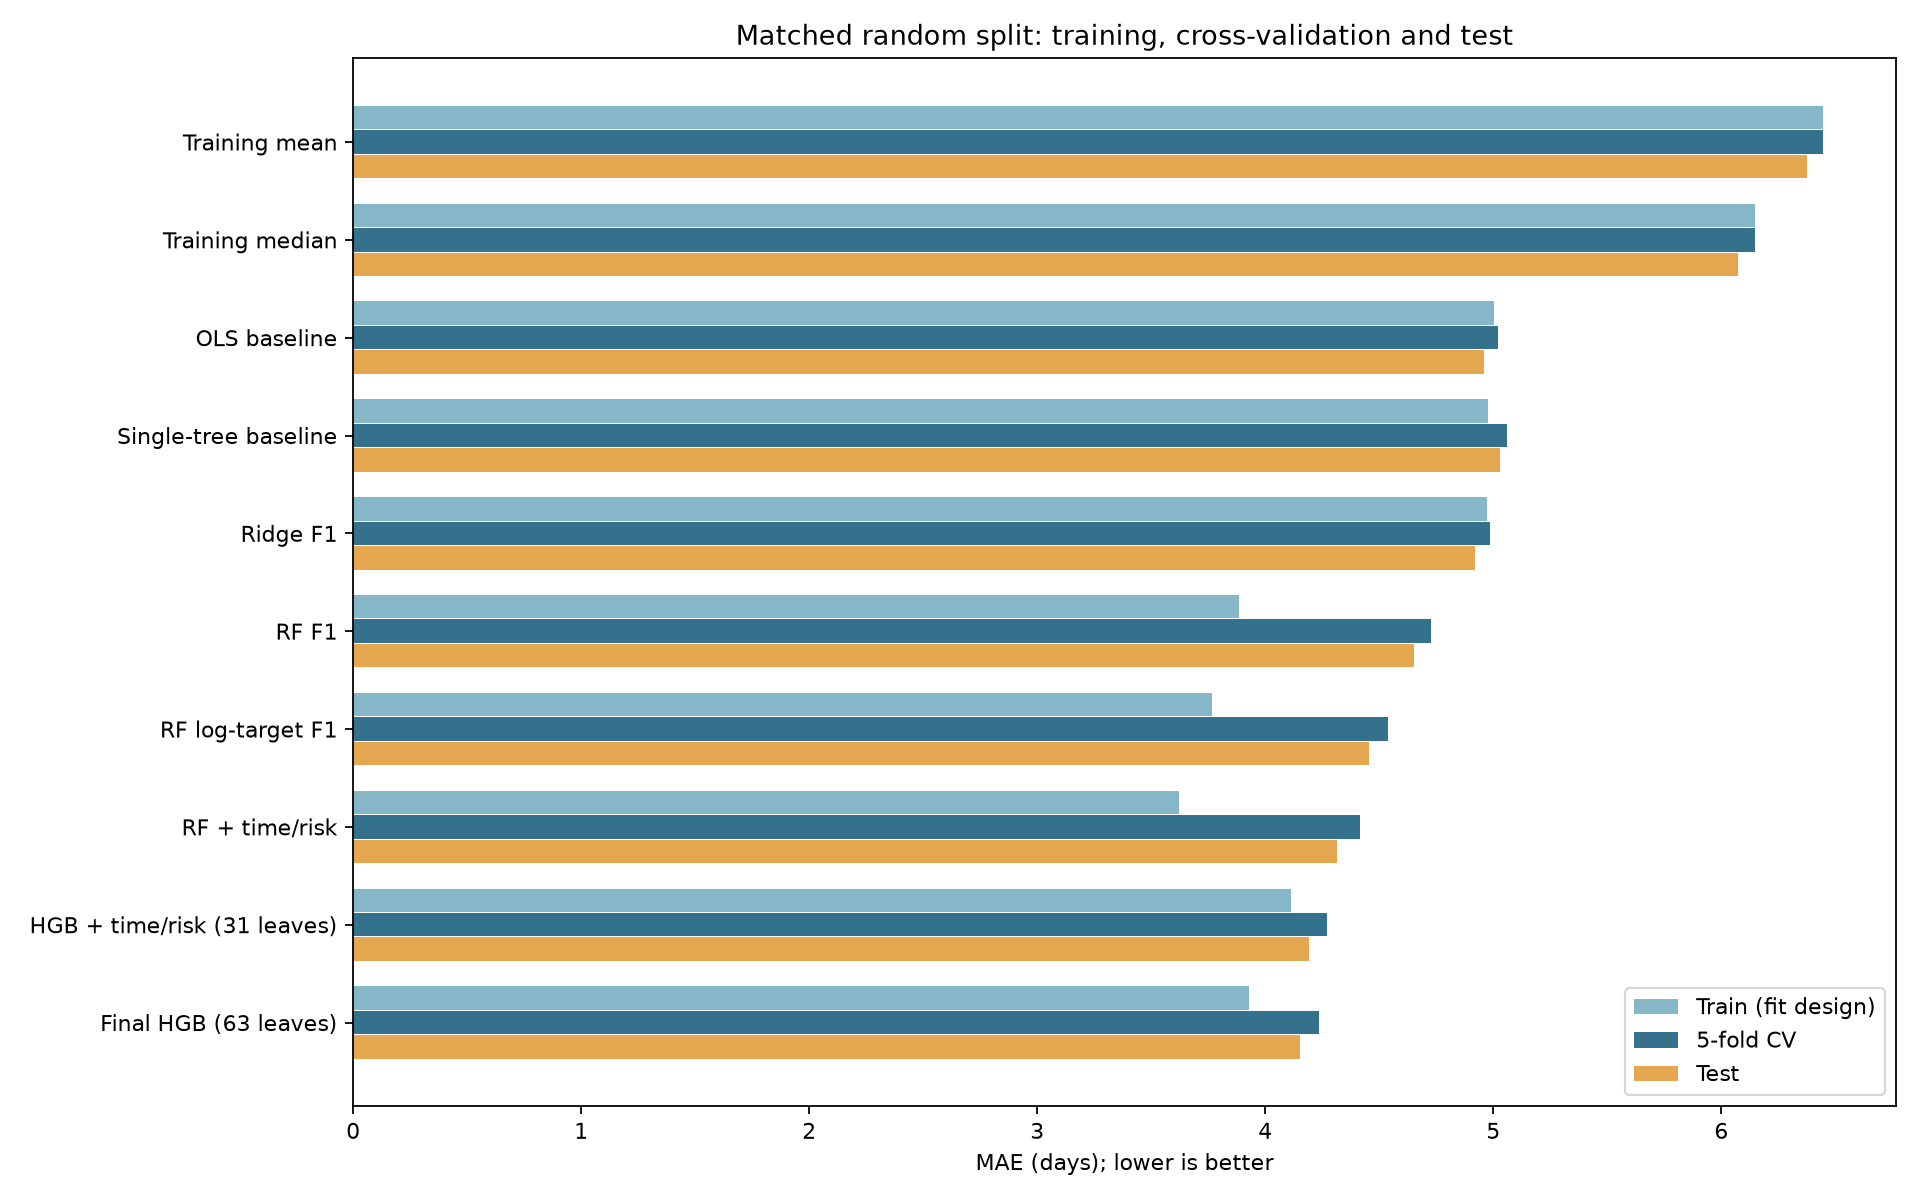

In [3]:
display(comparison[['model','Train_MAE_days','CV_MAE_mean_days','CV_MAE_SD_sample_days','Test_MAE_days','Test_RMSE_days','Test_R2']].round(4))
display(Image(filename=str(RESULTS/'figures/train_cv_test_comparison.png')))

### 2. Final HGB errors
All test orders are included in the plot. Duration slices depend on observed outcomes for diagnosis only, and never become purchase predictors.

,dimension,group,n,MAE_days,RMSE_days,R2,bias_days,within_3_days_pct
0,actual duration,0–7 days,8584,2.2940,3.1264,-2.9917,1.9441,72.2973
1,actual duration,7–14 days,13334,2.6044,3.5298,-2.0406,0.6293,67.7366
2,actual duration,14–30 days,8454,5.3738,6.7497,-1.6526,-4.1787,33.7473
3,actual duration,30–60 days,1365,18.8525,20.7559,-7.9130,-18.8266,2.4908
4,actual duration,>60 days,99,66.1881,74.5964,-4.4852,-66.1881,0.0000
5,route,All sellers same-state,11431,2.9544,5.7292,0.2210,-1.0426,69.9676
6,route,Any seller cross-state,20405,4.8205,8.2800,0.2842,-1.4987,49.6300


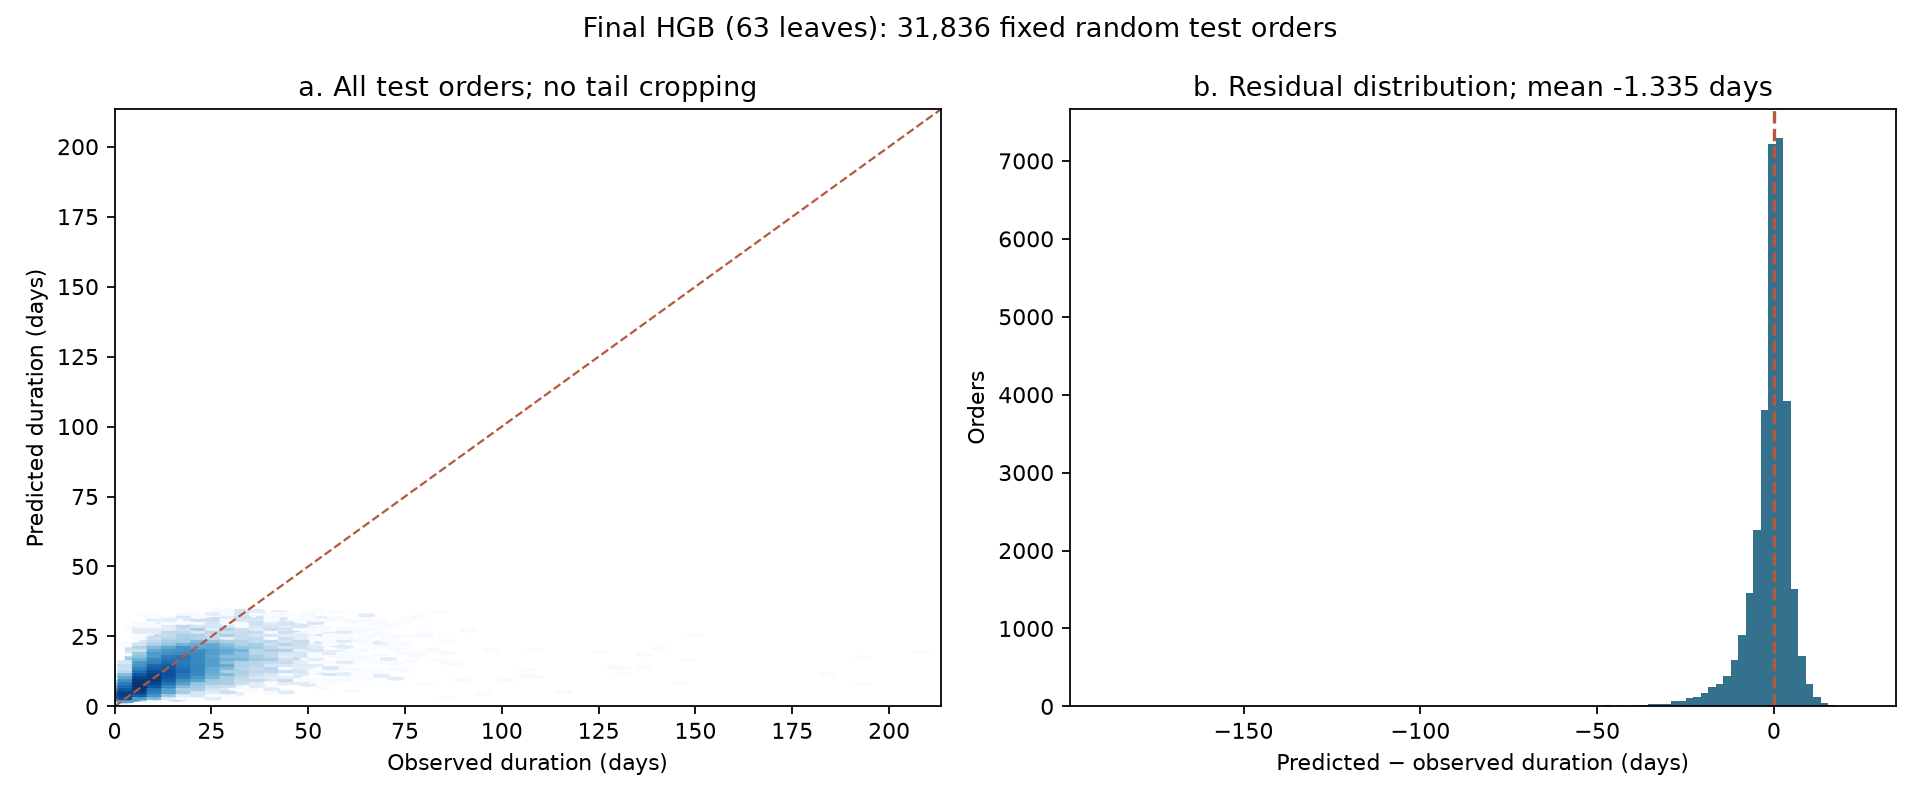

In [4]:
display(pd.read_csv(RESULTS/'tables/hgb_test_error_groups.csv').round(4))
display(Image(filename=str(RESULTS/'figures/hgb_test_errors.png')))

### 3. Final HGB interpretation
End-to-end grouped permutation on 8,000 fixed test orders, five repeats. MAE increase is in days. Raw inputs, derived interactions and auxiliary risk respond together; model/preprocessing remain frozen. Correlated group contributions are not additive or causal. Repeat SD is not a confidence interval.

,group,MAE_increase_mean_days,MAE_increase_SD_days,sample_n,repeats
0,Geography and route,1.3504,0.0328,8000,5
1,Purchase date and calendar,0.9771,0.0212,8000,5
2,Quoted promise,0.5302,0.0155,8000,5
3,Seller identity and composition,0.1026,0.0082,8000,5
4,Price and freight,0.0451,0.0069,8000,5
5,Product category and composition,0.0310,0.0048,8000,5
6,Product weight and volume,0.0266,0.0051,8000,5


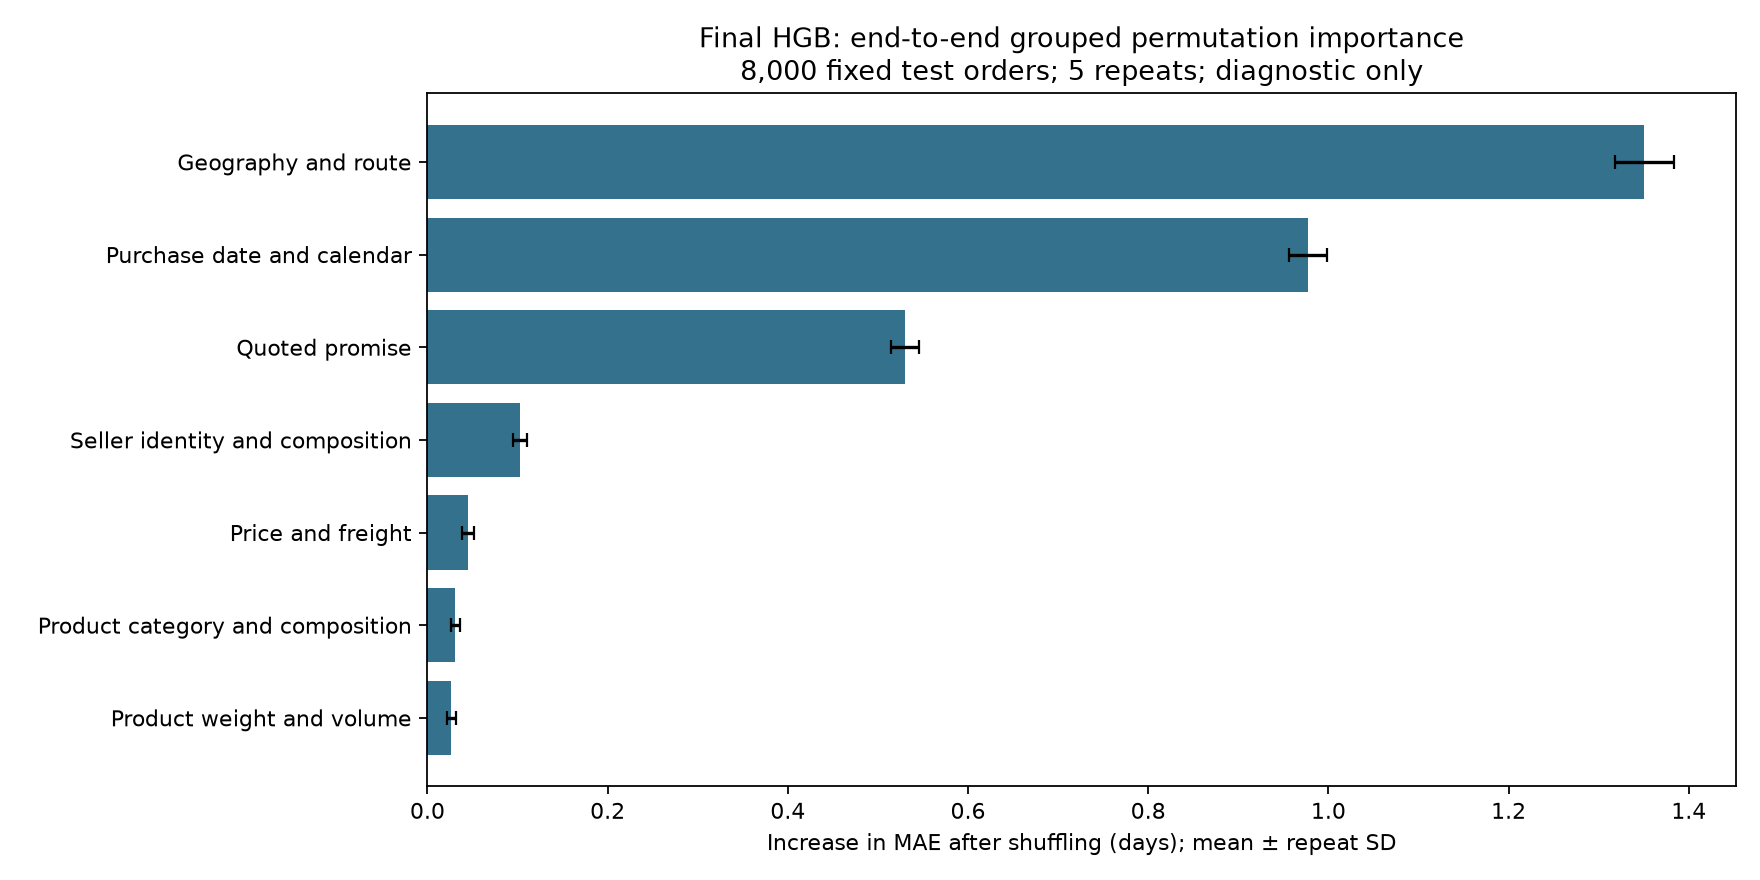

In [5]:
importance=pd.read_csv(RESULTS/'tables/hgb_grouped_permutation_importance.csv')
display(importance[['group','MAE_increase_mean_days','MAE_increase_SD_days','sample_n','repeats']].round(4))
display(Image(filename=str(RESULTS/'figures/hgb_grouped_permutation_importance.png')))

### 4. Latest stacking context
This separate nested procedure uses the same training orders and outer folds. Tuned Ridge/RF have fold-specific configurations and no learned-risk feature. Their outer scores are not the main table's fixed variant scores. No final stack Train/Test exists; unavailable cells must stay blank. HGB selection previously used these folds, so the procedure is retrospective rather than independent confirmation.

In [6]:
stack=pd.read_csv(RESULTS/'tables/stacking_outer_cv_comparison.csv')
display(stack[['label','mean_fold_MAE_days','fold_MAE_SD_days']].round(6))
hgb=stack.loc[stack.model.eq('hgb'),'mean_fold_MAE_days'].iloc[0]
combined=stack.loc[stack.model.eq('stack_three_tuned'),'mean_fold_MAE_days'].iloc[0]
print(f'Stacking difference: {(hgb-combined)*86400:.2f} seconds in mean CV MAE; no stack test score.')

,label,mean_fold_MAE_days,fold_MAE_SD_days
0,Fixed Ridge,5.035208,0.037053
1,Fixed random forest,4.806196,0.051700
2,Published HGB,4.237815,0.036900
3,Tuned Ridge,4.921914,0.036416
4,Tuned random forest,4.600224,0.043587
5,Fixed Ridge + forest: mean,4.841101,0.045195
6,Fixed Ridge + forest: MAE stack,4.799663,0.049929
7,Fixed Ridge + forest + HGB: mean,4.542078,0.042180
8,Fixed Ridge + forest + HGB: MAE stack,4.237815,0.036900
9,Tuned Ridge + forest: mean,4.663172,0.038355


Stacking difference: 36.20 seconds in mean CV MAE; no stack test score.


### 5. Evaluation-only chronology sensitivity
84 orders were flagged by earlier event chronology checks. This diagnostic omits 25 flagged test rows without changing the model or training population; it does not test retraining after exclusions.

In [7]:
display(pd.read_csv(RESULTS/'tables/chronology_evaluation_sensitivity.csv').round(6))
verification=json.loads((RESULTS/'verification.json').read_text())
assert verification['source_artifacts_unchanged'] and verification['CV_metrics_recomputed_from_complete_saved_OOF']
print('Complete saved OOF and test predictions verified; fixed models not reselected.')

,evaluation_cohort,n,MAE_days,RMSE_days,R2,bias_days,within_3_days_pct
0,All fixed test orders,31836,4.150492,7.465069,0.367543,-1.334931,56.932404
1,Excluding chronology flags at evaluation only,31811,4.152268,7.467624,0.367207,-1.336724,56.914275
2,Chronology-flagged test orders only,25,1.889691,2.678544,0.542994,0.946775,80.000000


Complete saved OOF and test predictions verified; fixed models not reselected.


## Takeaways
Geography/routes, purchase date/calendar and quoted promises show the largest grouped permutation increases. The learned-risk increment is small in the matched CV ablation. Overall gains do not remove severe slow-order underprediction: 30–60 day MAE **18.8525** and >60 day MAE **66.1881**. The report should keep the single HGB and describe stacking as a negligible-gain development comparison.

Evidence mapping and commands: [report_evidence_guide.md](../docs/report_evidence_guide.md). Full fixed-model reproduction uses `scripts/reproduce_report_supplement.py`; add `--with-cv` to rerun five-fold comparisons. This notebook reads aggregates only.